In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### ***Data***

Sample size (original): 32
          Steps  Weight
count     32.00   32.00
mean    4658.81   63.50
std     3591.08   13.12
min        0.00   42.00
25%     1824.75   55.00
50%     4656.00   63.50
75%     7000.00   68.50
max    15000.00  108.00


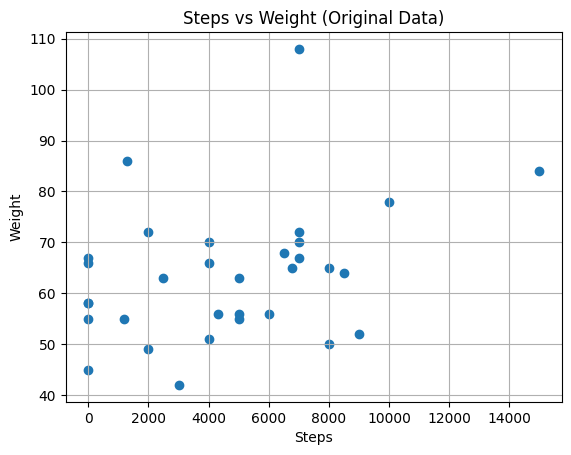

In [24]:
df_original = pd.read_csv('data.csv')
print('Sample size (original):', len(df_original))
print(df_original[['Steps', 'Weight']].describe().round(2))

plt.scatter(df_original['Steps'], df_original['Weight'])
plt.xlabel('Steps')
plt.ylabel('Weight')
plt.title('Steps vs Weight (Original Data)')
plt.grid()
plt.show()

### ***Model***

In [25]:
def model(x, y):
    n = len(x)
    xm = x.mean()
    ym = y.mean()

    Sxx = np.sum((x - xm) ** 2)
    Sxy = np.sum((x - xm) * (y - ym))
    Syy = np.sum((y - ym) ** 2)

    b1 = Sxy / Sxx
    b0 = ym - b1 * xm

    yhat = b0 + b1 * x
    res = y - yhat
    SSE = np.sum(res ** 2)

    Se = np.sqrt(SSE / (n - 2))
    R2 = 1 - SSE / Syy
    adjR2 = 1 - (SSE / (n - 2)) / (Syy / (n - 1))
    r = Sxy / np.sqrt(Sxx * Syy)

    Sb1 = Se / np.sqrt(Sxx)
    Sb0 = Se * np.sqrt(1 / n + xm ** 2 / Sxx)

    p_b1 = 2 * (1 - stats.t.cdf(abs(b1 / Sb1), df=n - 2))
    p_b0 = 2 * (1 - stats.t.cdf(abs(b0 / Sb0), df=n - 2))

    ci_b0 = (b0 - 1.96 * Sb0, b0 + 1.96 * Sb0)
    ci_b1 = (b1 - 1.96 * Sb1, b1 + 1.96 * Sb1)

    return b0, b1, yhat, res, Se, R2, adjR2, r, Sb0, Sb1, p_b0, p_b1, ci_b0, ci_b1, n


def print_regression_summary(label, b0, b1, Se, R2, adjR2, r, Sb0, Sb1, p_b0, p_b1, ci_b0, ci_b1):
    print(label)
    print('Regression Description:')
    print(f'Intercept (b0): {b0:.6f}')
    print(f'Slope (b1): {b1:.6f}')
    print(f'R-squared: {R2:.6f}')
    print(f'Adjusted R-squared: {adjR2:.6f}')
    print(f'Standard Error of Estimate (Se): {Se:.6f}')
    print(f'Correlation Coefficient (r): {r:.6f}')
    print(f'Standard Error of b0 (Sb0): {Sb0:.6f}')
    print(f'Standard Error of b1 (Sb1): {Sb1:.6f}')
    print(f'P-value for b0: {p_b0:.6f}')
    print(f'P-value for b1: {p_b1:.6f}')
    print(f'95% Confidence Interval for b0: ({ci_b0[0]:.6f}, {ci_b0[1]:.6f})')
    print(f'95% Confidence Interval for b1: ({ci_b1[0]:.6f}, {ci_b1[1]:.6f})')
    print()


def analyze_dataset(df_input, title='Analysis', top_k=2):
    data = df_input.copy()
    x = data['Steps'].to_numpy()/1000
    y = data['Weight'].to_numpy()

    b0, b1, yhat, res, Se, R2, adjR2, r, Sb0, Sb1, p_b0, p_b1, ci_b0, ci_b1, n = model(x, y)

    print('-------------------------------------------------------')
    print(f'------------ {title} ------------')
    print("-------------------------------------------------------")
    print(f'Sample size: {n}')
    print_regression_summary('Model with all observations:', b0, b1, Se, R2, adjR2, r, Sb0, Sb1, p_b0, p_b1, ci_b0, ci_b1)

    plt.figure(figsize=(8, 6))
    plt.scatter(x / 100, y)
    plt.plot(x / 100, yhat, 'r')
    plt.xlabel('Daily Steps (Thousand)')
    plt.ylabel('Body Weight (kg)')
    plt.title(f'Steps per Day vs Body Weight - {title}')
    plt.show()

    # Standardized residuals

    std_res = res / Se

    plt.figure(figsize=(8, 6))
    plt.scatter(yhat, std_res)
    plt.axhline(0, color='red', linestyle='--')
    plt.axhline(2, color='red', linestyle='--')
    plt.axhline(-2, color='red', linestyle='--')
    plt.ylim(-3, 3)
    plt.xlabel('Fitted Values')
    plt.ylabel('Standardized Residuals')
    plt.title(f'Standardized Residuals vs Fitted Values - {title}')
    plt.show()

    # Normal Q-Q plot of residuals

    plt.figure(figsize=(8, 6))
    stats.probplot(res, dist='norm', plot=plt)
    plt.title(f'Normal Q-Q Plot of Residuals - {title}')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles (residuals)')
    plt.grid()
    plt.show()

    # Cook's Distance

    p = 1
    cooks = np.zeros(n)
    influential_obs = []

    for i in range(n):
        x_drop = np.delete(x, i)
        y_drop = np.delete(y, i)

        b0_i, b1_i, *_ = model(x_drop, y_drop)
        yhat_without_i = b0_i + b1_i * x
        cooks[i] = np.sum((yhat - yhat_without_i) ** 2) / (Se ** 2 * (p + 1))

    max_idx = int(np.argmax(cooks))
    influential_obs.append({
        'index': max_idx,
        'steps': x[max_idx],
        'weight': y[max_idx],
        'Ci': cooks[max_idx]
    })

    print("Cook's Distance")
    print()
    for i in range(n):
        print(f"{i+1} | steps={x[i]:5.0f} | weight={y[i]:3.0f} kg | Ci = {cooks[i]:.4f}")
    print()
    print(f"Most influential: Obs {max_idx+1}  (Ci = {cooks[max_idx]:.4f})")
    print(f'Influential observations: {influential_obs}')
    print()

    plt.figure(figsize=(10, 4))
    plt.bar(range(1, n + 1), cooks, edgecolor='navy', alpha=0.8, label="Cook's Distance")
    plt.xlabel('Observation Number')
    plt.ylabel("Cook's Distance")
    plt.title(f"Cook's Distance - {title}")
    plt.legend()
    plt.grid(alpha=0.3, axis='y')
    plt.show()

    x_drop1 = np.delete(x, max_idx)
    y_drop1 = np.delete(y, max_idx)
    b0_d, b1_d, yhat_d, res_d, Se_d, R2_d, adjR2_d, r_d, Sb0_d, Sb1_d, p_b0_d, p_b1_d, ci_b0_d, ci_b1_d, n_d = model(x_drop1, y_drop1)
    print_regression_summary('Model without most influential observation:', b0_d, b1_d, Se_d, R2_d, adjR2_d, r_d, Sb0_d, Sb1_d, p_b0_d, p_b1_d, ci_b0_d, ci_b1_d)

    plt.figure(figsize=(8, 6))
    plt.scatter(x_drop1 / 100, y_drop1)
    plt.plot(x_drop1 / 100, yhat_d, 'r')
    plt.title(f'Steps vs Weight (without most influential) - {title}')
    plt.xlabel('Daily Steps (Thousand)')
    plt.ylabel('Body Weight (kg)')
    plt.show()

    k = min(top_k, n - 1)
    top_indices = np.argsort(cooks)[-k:][::-1]
    influential_topk = []
    for i in top_indices:
        influential_topk.append({
            'index': int(i),
            'steps': x[i],
            'weight': y[i],
            'Ci': cooks[i]
        })

    print(f'Top {k} Influential Observations:')
    for obs in influential_topk:
        print(obs)
    print()

    x_new = np.delete(x, top_indices)
    y_new = np.delete(y, top_indices)
    b0_new, b1_new, yhat_new, res_new, Se_new, R2_new, adjR2_new, r_new, Sb0_new, Sb1_new, p_b0_new, p_b1_new, ci_b0_new, ci_b1_new, n_new = model(x_new, y_new)
    print_regression_summary(f'Model after removing top {k} influential observations:', b0_new, b1_new, Se_new, R2_new, adjR2_new, r_new, Sb0_new, Sb1_new, p_b0_new, p_b1_new, ci_b0_new, ci_b1_new)

    plt.figure(figsize=(8, 6))
    plt.scatter(x_new / 100, y_new)
    plt.plot(x_new / 100, yhat_new, 'r')
    plt.title(f'Steps vs Weight (without top {k} influential) - {title}')
    plt.xlabel('Daily Steps (Tousand)')
    plt.ylabel('Body Weight (kg)')
    plt.show()

    return {
        'data': data,
        'all': {'b0': b0, 'b1': b1, 'R2': R2, 'adjR2': adjR2, 'Se': Se},
        'without_one': {'b0': b0_d, 'b1': b1_d, 'R2': R2_d, 'adjR2': adjR2_d, 'Se': Se_d},
        'without_topk': {'b0': b0_new, 'b1': b1_new, 'R2': R2_new, 'adjR2': adjR2_new, 'Se': Se_new},
        'cooks': cooks,
        'top_indices': top_indices
    }

### ***Dropping Missing Value :***

Sample size after dropping Steps 26
-------------------------------------------------------
------------ After Dropping Steps ------------
-------------------------------------------------------
Sample size: 26
Model with all observations:
Regression Description:
Intercept (b0): 57.030827
Slope (b1): 1.342875
R-squared: 0.089842
Adjusted R-squared: 0.051919
Standard Error of Estimate (Se): 13.501906
Correlation Coefficient (r): 0.299736
Standard Error of b0 (Sb0): 5.660230
Standard Error of b1 (Sb1): 0.872467
P-value for b0: 0.000000
P-value for b1: 0.136845
95% Confidence Interval for b0: (45.936776, 68.124878)
95% Confidence Interval for b1: (-0.367161, 3.052911)



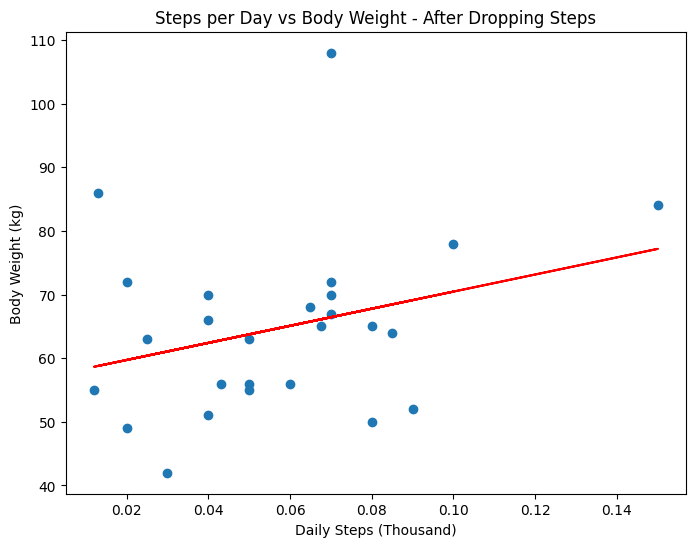

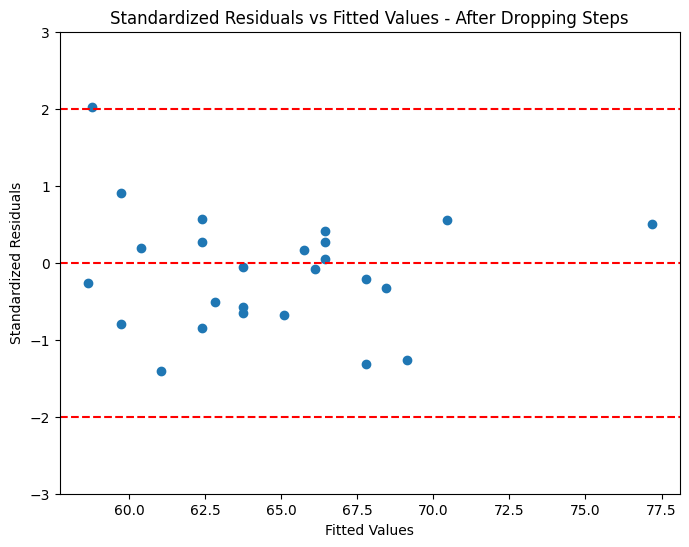

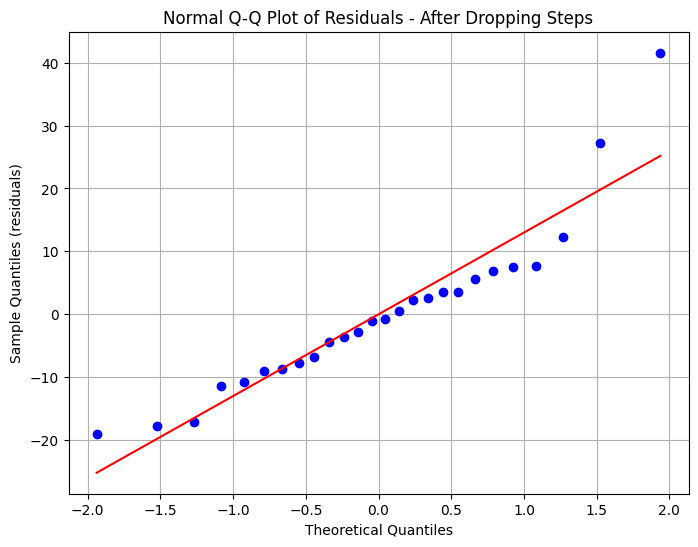

Cook's Distance

1 | steps=    2 | weight= 49 kg | Ci = 0.0373
2 | steps=   10 | weight= 78 kg | Ci = 0.0228
3 | steps=    7 | weight= 65 kg | Ci = 0.0002
4 | steps=    2 | weight= 63 kg | Ci = 0.0018
5 | steps=    7 | weight= 72 kg | Ci = 0.0042
6 | steps=    8 | weight= 64 kg | Ci = 0.0044
7 | steps=    7 | weight= 67 kg | Ci = 0.0000
8 | steps=    5 | weight= 55 kg | Ci = 0.0093
9 | steps=    9 | weight= 52 kg | Ci = 0.0793
10 | steps=    3 | weight= 42 kg | Ci = 0.0802
11 | steps=    5 | weight= 63 kg | Ci = 0.0001
12 | steps=    7 | weight=108 kg | Ci = 0.2347
13 | steps=    5 | weight= 56 kg | Ci = 0.0073
14 | steps=    7 | weight= 70 kg | Ci = 0.0017
15 | steps=    1 | weight= 86 kg | Ci = 0.3170
16 | steps=    4 | weight= 56 kg | Ci = 0.0066
17 | steps=    1 | weight= 55 kg | Ci = 0.0059
18 | steps=    8 | weight= 50 kg | Ci = 0.0587
19 | steps=   15 | weight= 84 kg | Ci = 0.1395
20 | steps=    6 | weight= 68 kg | Ci = 0.0006
21 | steps=    2 | weight= 72 kg | Ci = 0.0490
22 | 

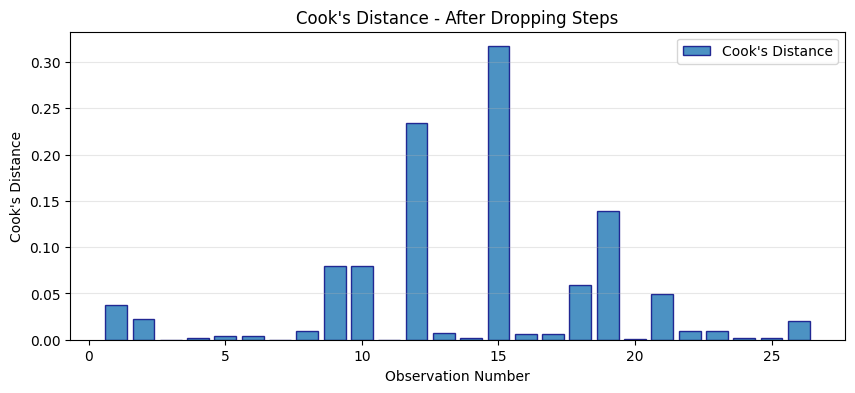

Model without most influential observation:
Regression Description:
Intercept (b0): 52.553001
Slope (b1): 1.916154
R-squared: 0.185449
Adjusted R-squared: 0.150034
Standard Error of Estimate (Se): 12.392868
Correlation Coefficient (r): 0.430638
Standard Error of b0 (Sb0): 5.535788
Standard Error of b1 (Sb1): 0.837361
P-value for b0: 0.000000
P-value for b1: 0.031637
95% Confidence Interval for b0: (41.702857, 63.403144)
95% Confidence Interval for b1: (0.274926, 3.557382)



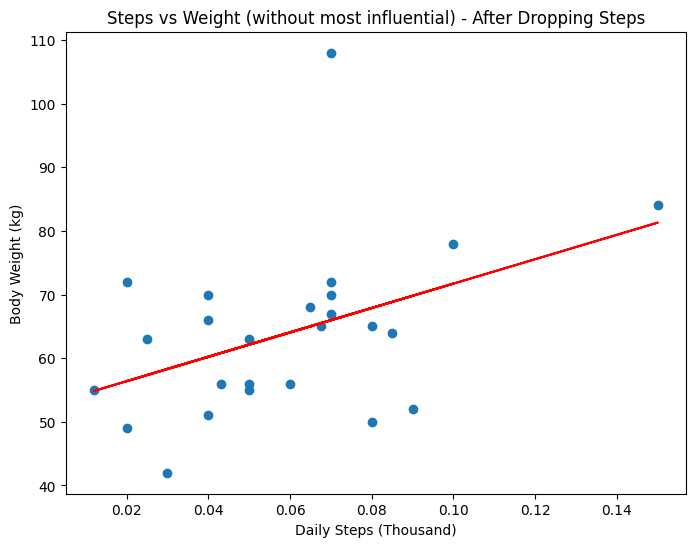

Top 2 Influential Observations:
{'index': 14, 'steps': np.float64(1.299), 'weight': np.int64(86), 'Ci': np.float64(0.3169753061370029)}
{'index': 11, 'steps': np.float64(7.0), 'weight': np.int64(108), 'Ci': np.float64(0.23472341772928243)}

Model after removing top 2 influential observations:
Regression Description:
Intercept (b0): 52.085410
Slope (b1): 1.697294
R-squared: 0.271745
Adjusted R-squared: 0.238642
Standard Error of Estimate (Se): 8.742558
Correlation Coefficient (r): 0.521291
Standard Error of b0 (Sb0): 3.906381
Standard Error of b1 (Sb1): 0.592389
P-value for b0: 0.000000
P-value for b1: 0.008995
95% Confidence Interval for b0: (44.428902, 59.741917)
95% Confidence Interval for b1: (0.536212, 2.858377)



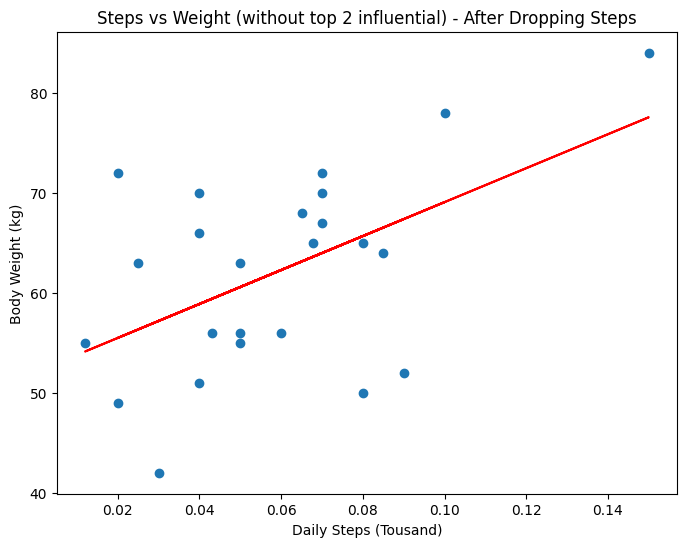

In [26]:
df_no_zero = df_original[df_original['Steps'] != 0].copy()
print('Sample size after dropping Steps', len(df_no_zero))
result_drop = analyze_dataset(df_no_zero, title='After Dropping Steps')

### ***Filling Missing Values :***

In [27]:
# To fill Missing Steps with random values based on Routine

def fill_zero_steps(dataframe, seed=42):
    df_filled = dataframe.copy()
    np.random.seed(seed)

    for i in range(len(df_filled)):
        if df_filled.iloc[i]['Steps'] == 0:
            routine = str(df_filled.iloc[i]['Routine']).strip().lower()

            if 'physically active' in routine:
                df_filled.at[i, 'Steps'] = np.random.randint(10000, 15001)
            elif 'mostly seating at desk' in routine:
                df_filled.at[i, 'Steps'] = np.random.randint(2000, 5001)
            else:
                df_filled.at[i, 'Steps'] = np.random.randint(1000, 15001)

    return df_filled

Sample size after filling Steps 32
-------------------------------------------------------
------------ After Filling Steps ------------
-------------------------------------------------------
Sample size: 32
Model with all observations:
Regression Description:
Intercept (b0): 57.628072
Slope (b1): 1.006647
R-squared: 0.057912
Adjusted R-squared: 0.026510
Standard Error of Estimate (Se): 12.949579
Correlation Coefficient (r): 0.240650
Standard Error of b0 (Sb0): 4.892528
Standard Error of b1 (Sb1): 0.741270
P-value for b0: 0.000000
P-value for b1: 0.184589
95% Confidence Interval for b0: (48.038718, 67.217427)
95% Confidence Interval for b1: (-0.446242, 2.459535)



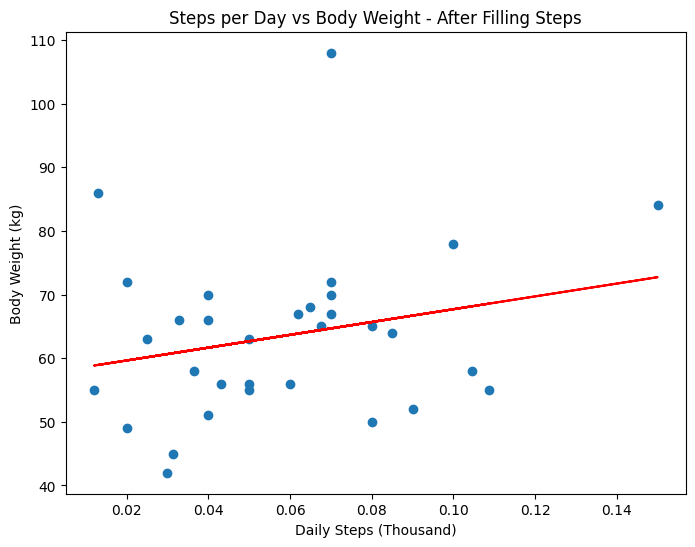

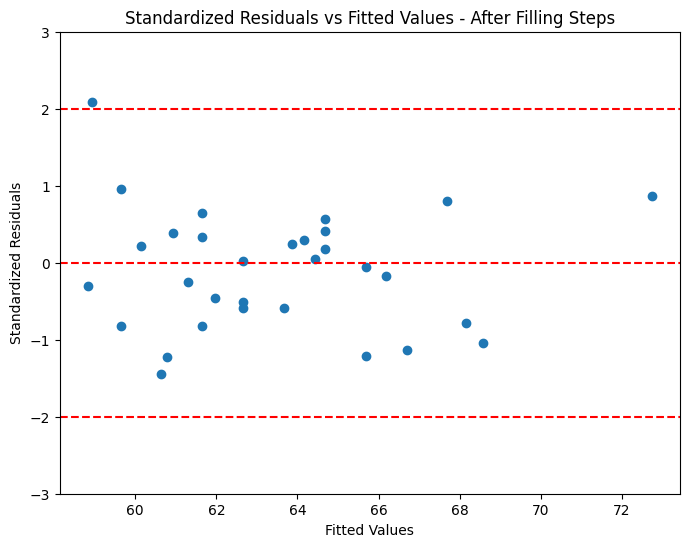

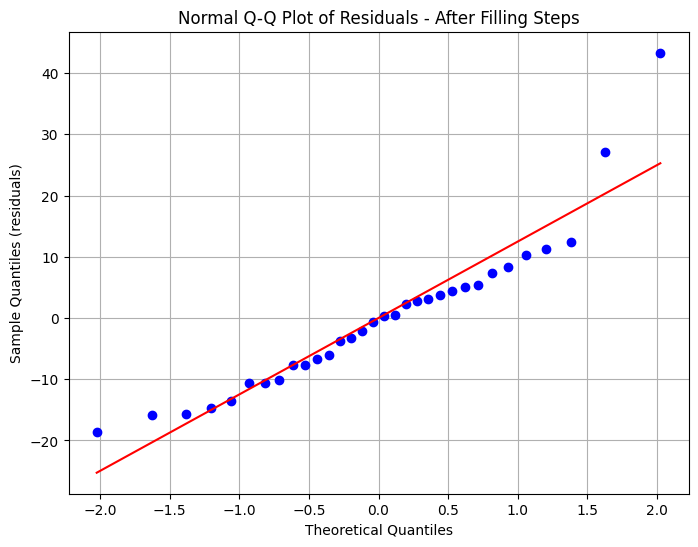

Cook's Distance

1 | steps=    2 | weight= 49 kg | Ci = 0.0316
2 | steps=   10 | weight= 78 kg | Ci = 0.0336
3 | steps=   11 | weight= 55 kg | Ci = 0.0797
4 | steps=    7 | weight= 65 kg | Ci = 0.0000
5 | steps=    2 | weight= 63 kg | Ci = 0.0019
6 | steps=    7 | weight= 72 kg | Ci = 0.0061
7 | steps=    8 | weight= 64 kg | Ci = 0.0009
8 | steps=    7 | weight= 67 kg | Ci = 0.0006
9 | steps=    5 | weight= 55 kg | Ci = 0.0063
10 | steps=    9 | weight= 52 kg | Ci = 0.0471
11 | steps=    3 | weight= 42 kg | Ci = 0.0672
12 | steps=    5 | weight= 63 kg | Ci = 0.0000
13 | steps=    3 | weight= 66 kg | Ci = 0.0044
14 | steps=    7 | weight=108 kg | Ci = 0.2149
15 | steps=    5 | weight= 56 kg | Ci = 0.0047
16 | steps=    7 | weight= 70 kg | Ci = 0.0032
17 | steps=    1 | weight= 86 kg | Ci = 0.2651
18 | steps=    4 | weight= 56 kg | Ci = 0.0045
19 | steps=    1 | weight= 55 kg | Ci = 0.0055
20 | steps=    8 | weight= 50 kg | Ci = 0.0376
21 | steps=    3 | weight= 45 kg | Ci = 0.0459
22 | 

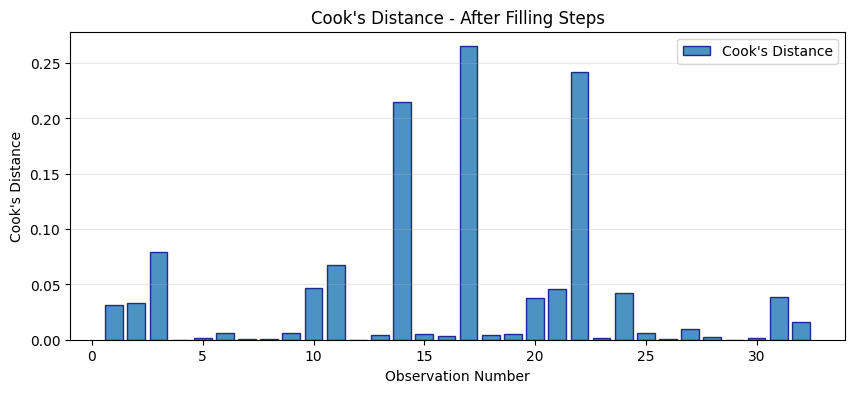

Model without most influential observation:
Regression Description:
Intercept (b0): 54.087663
Slope (b1): 1.452738
R-squared: 0.124399
Adjusted R-squared: 0.094206
Standard Error of Estimate (Se): 12.060388
Correlation Coefficient (r): 0.352703
Standard Error of b0 (Sb0): 4.796459
Standard Error of b1 (Sb1): 0.715702
P-value for b0: 0.000000
P-value for b1: 0.051640
95% Confidence Interval for b0: (44.686602, 63.488723)
95% Confidence Interval for b1: (0.049961, 2.855515)



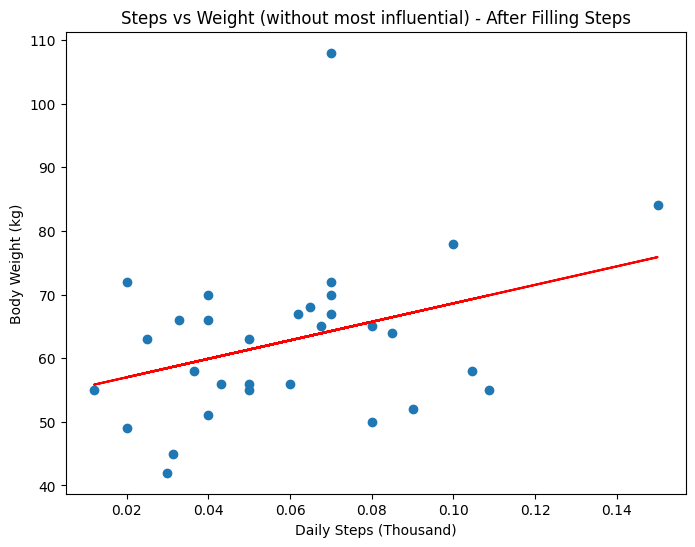

Top 2 Influential Observations:
{'index': 16, 'steps': np.float64(1.299), 'weight': np.int64(86), 'Ci': np.float64(0.2650783199817968)}
{'index': 21, 'steps': np.float64(15.0), 'weight': np.int64(84), 'Ci': np.float64(0.24158791805605698)}

Model after removing top 2 influential observations:
Regression Description:
Intercept (b0): 55.967690
Slope (b1): 1.074003
R-squared: 0.052978
Adjusted R-squared: 0.019156
Standard Error of Estimate (Se): 12.132177
Correlation Coefficient (r): 0.230170
Standard Error of b0 (Sb0): 5.352925
Standard Error of b1 (Sb1): 0.858138
P-value for b0: 0.000000
P-value for b1: 0.221089
95% Confidence Interval for b0: (45.475958, 66.459423)
95% Confidence Interval for b1: (-0.607948, 2.755954)



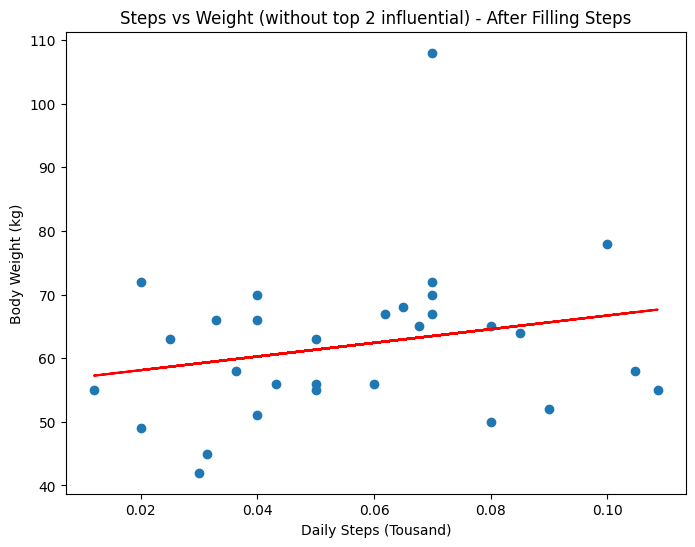

In [28]:
df_filled = fill_zero_steps(df_original, seed=42)
print('Sample size after filling Steps', len(df_filled))
result_filled = analyze_dataset(df_filled, title='After Filling Steps')